In [1]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

In [2]:
import os
os.environ["OMP_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"
os.environ["OPENBLAS_NUM_THREADS"]="1"
os.environ["NUMEXPR_NUM_THREADS"]="1"


In [3]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

## fig1

In [4]:
import glob, re
import pandas as pd
import xarray as xr

files = sorted(glob.glob("/data/shared_data/satellite_data/MODIS/monthly/netcdf_subset/MOD08_M3_*.nc"))

def add_time(ds, filename=None):

    m = re.search(r"MOD08_M3_(\d{6})\.nc$", filename)
    yyyymm = m.group(1)
    t = pd.to_datetime(yyyymm + "01", format="%Y%m%d")
    return ds.expand_dims(time=[t])


datasets = []
for f in files:
    ds = xr.open_dataset(f)
    ds = add_time(ds, f)
    datasets.append(ds)

ds = xr.concat(datasets, dim="time").sortby("time")
print(ds.dims)


FrozenMappingWarningOnValuesAccess({'time': 155, 'lat': 180, 'lon': 360, 'Effective_Optical_Depth_Average_Ocean_Micron_Levels': 7, 'Pressure_Level_mod08': 20, 'XDim_mod08': 360, 'YDim_mod08': 180, 'Effective_Optical_Depth_Average_Ocean_Micron_Levels_mod08': 7})


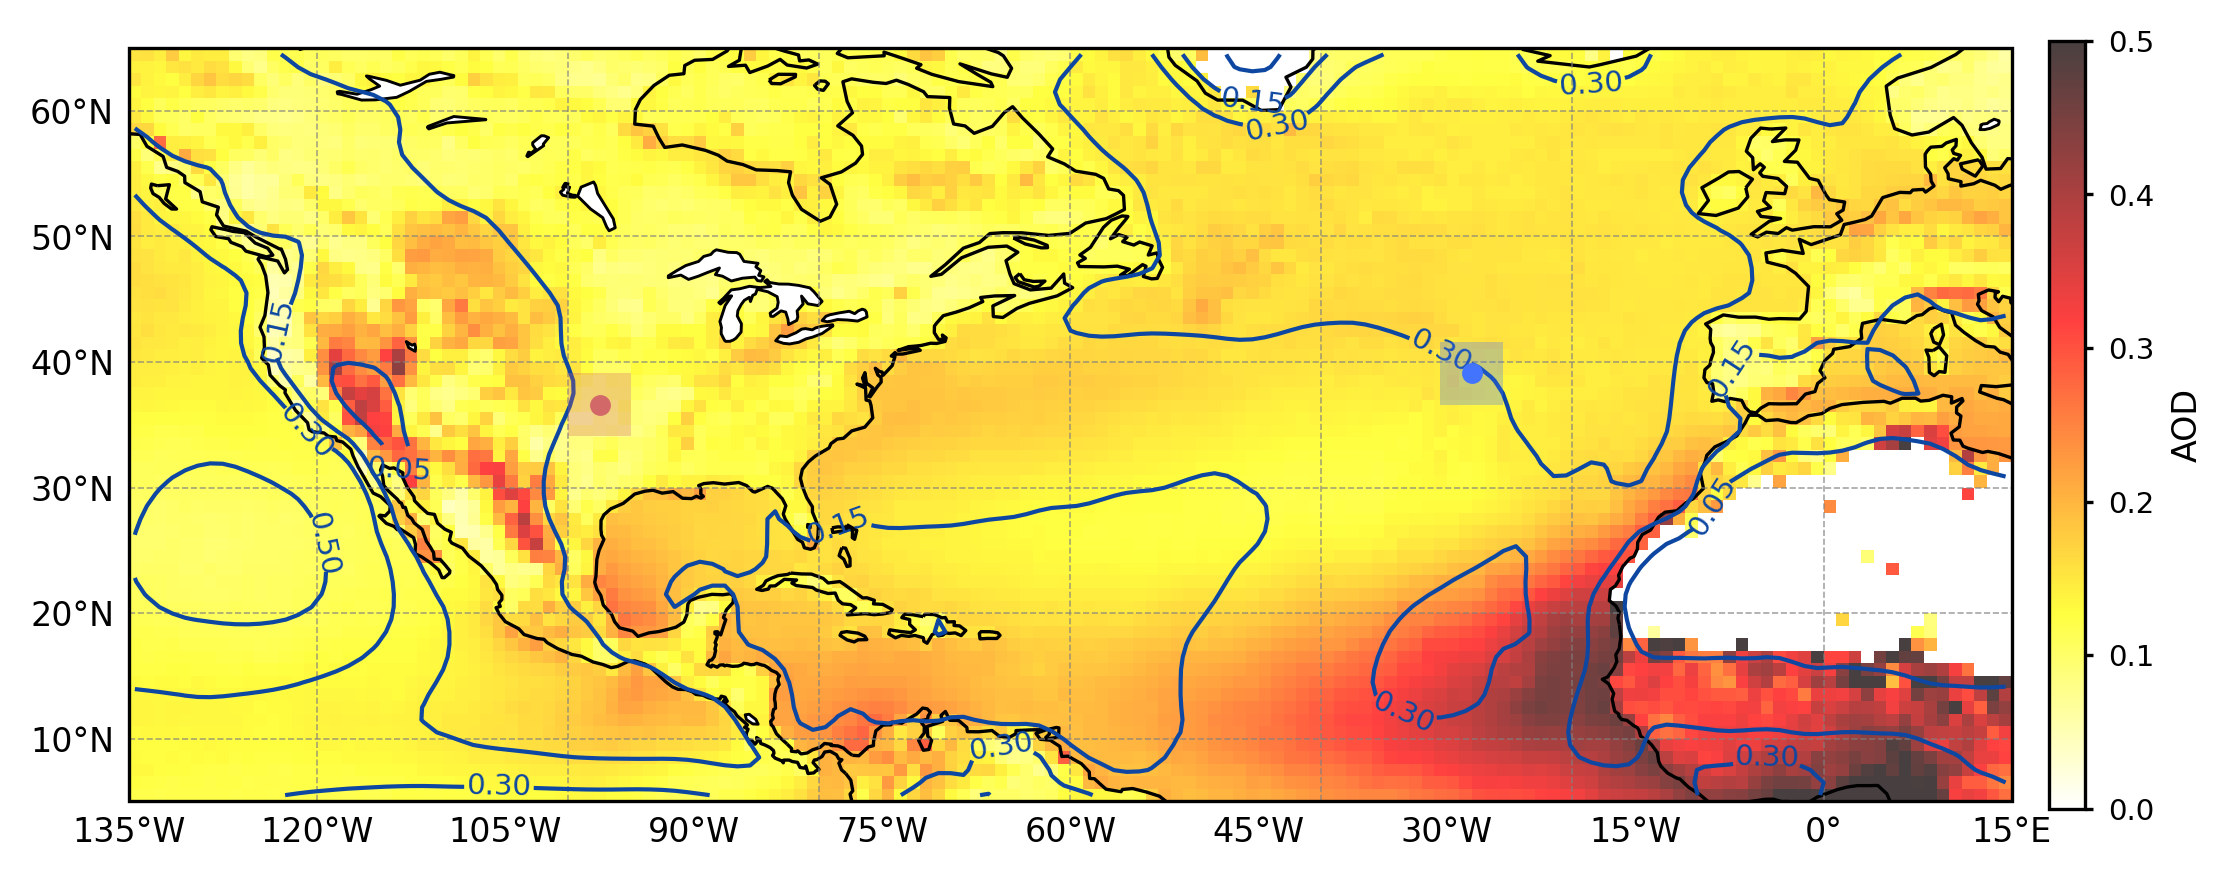

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle

ds_sel = ds.sel(time=slice("2000-01-01", "2012-12-01"))

lon, lat = ds["lon"].values, ds["lat"].values
aod = ds_sel["Optical_Depth_Land_And_Ocean_Mean_Mean"].mean("time", skipna=True).values
cf  = ds_sel["Cloud_Fraction_1L_Liquid_FMean"].mean("time", skipna=True).values

lat_ena, lon_ena = 39.0916, -28.0257
lat_sgp, lon_sgp = 36.607322, -97.487643

# ===== smooth CF =====
m = np.isfinite(cf)
cf0 = np.where(m, cf, 0)
w = gaussian_filter(m.astype(float), sigma=1.2)
cf_smooth = gaussian_filter(cf0, sigma=1.2) / np.where(w == 0, np.nan, w)

# ===== subset region =====
lon_min, lon_max = -135, 15
lat_min, lat_max = 5, 65

ix = (lon >= lon_min) & (lon <= lon_max)
iy = (lat >= lat_min) & (lat <= lat_max)

lon_sub = lon[ix]
lat_sub = lat[iy]
Lon_sub, Lat_sub = np.meshgrid(lon_sub, lat_sub)

aod_sub = aod[np.ix_(iy, ix)]
cf_sub  = cf_smooth[np.ix_(iy, ix)]

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=300, subplot_kw={"projection": proj})

def base_map(ax):
    ax.add_feature(cfeature.LAKES.with_scale("110m"), facecolor="#FFFFFF", edgecolor="k", linewidth=0.7)
    ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#FFFFFF")
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.8)

    xt = np.arange(-180, 181, 15)
    yt = np.arange(-90, 91, 10)
    ax.set_xticks(xt, crs=proj)
    ax.set_yticks(yt, crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.gridlines(draw_labels=False, linewidth=0.4, linestyle="--", color="gray", alpha=0.7)

    ax.plot(lon_sgp, lat_sgp, "o", color="#d26868", ms=4, transform=proj, zorder=5)
    ax.plot(lon_ena, lat_ena, "o", color="#4374fe", ms=4, transform=proj, zorder=5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

base_map(ax)

pcm = ax.pcolormesh(
    Lon_sub, Lat_sub, aod_sub,
    vmin=0, vmax=0.5, cmap="hot_r",
    shading="auto", alpha=0.75, transform=proj
)

levels = [0.05, 0.15, 0.3, 0.5]
cs = ax.contour(
    Lon_sub, Lat_sub, cf_sub,
    levels=levels, colors="#0d47a1",
    linewidths=1.0, transform=proj
)

ax.clabel(cs, levels=levels, fmt="%.2f", fontsize=7, inline=True, inline_spacing=2)

ax.add_patch(Rectangle(
    (lon_sgp - 2.5, lat_sgp - 2.5), 5, 5,
    facecolor="#d26868", alpha=0.3,
    linewidth=1.2, transform=proj, zorder=4
))
ax.add_patch(Rectangle(
    (lon_ena - 2.5, lat_ena - 2.5), 5, 5,
    facecolor="#4374fe", alpha=0.3,
    linewidth=1.2, transform=proj, zorder=4
))


ax.tick_params(axis="both", which="both", length=0, width=0, labelsize=8)

# ===== custom colorbar =====
cax = fig.add_axes([0.86, 0.18, 0.015, 0.64])   # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label("AOD", fontsize=8)
cbar.set_ticks(np.arange(0, 0.51, 0.1))
cbar.ax.tick_params(labelsize=7, length=2)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("figsave/study_area_new.pdf", dpi=300, bbox_inches='tight')
plt.show()